# Simple Hourly Bids — Hallingdal Wind Farm (NO2)

**Scenario:** Hallingdal Vind AS operates a 120 MW wind farm in Norway's NO2 bidding zone.
The operations team needs to submit day-ahead supply bids for the next delivery day.
Wind generation forecasts drive a merit-order curve per MTU: the cheaper MW (high-wind
periods) are offered at lower prices, with progressively more expensive MW at higher prices.

This notebook demonstrates:
- Constructing 15-minute MTU intervals for a full delivery day
- Building `PriceQuantityCurve` supply curves from forecast data
- Creating `SimpleBid` objects validated against EUPHEMIA rules
- Visualising the supply curve step-function for selected hours

## Prerequisites

```bash
pip install nexa-bidkit matplotlib
# or, from source:
poetry install
```

In [1]:
from datetime import datetime, timezone
from decimal import Decimal

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

from nexa_bidkit.bids import simple_bid_from_curve
from nexa_bidkit.curves import (
    to_dataframe as curves_to_df,
    get_curve_summary,
)
from nexa_bidkit.types import (
    BiddingZone,
    CurveType,
    MTUDuration,
    MTUInterval,
    PriceQuantityStep,
    PriceQuantityCurve,
)

print("nexa-bidkit imports OK")

nexa-bidkit imports OK


## 1. Define the Delivery Day

EU power markets use UTC+1 (CET) for day-ahead auctions. The delivery day
runs 00:00–24:00 CET. We use `timezone.utc` internally and localise to CET for display.
After the MTU transition on 30 Sept 2025, NO2 uses 15-minute MTUs (96 per day).

In [2]:
import zoneinfo

CET = zoneinfo.ZoneInfo("Europe/Oslo")
UTC = timezone.utc

# Delivery day: 2026-03-15 (next day from bid preparation)
delivery_date = datetime(2026, 3, 15, 0, 0, 0, tzinfo=CET)

MTU_DURATION = MTUDuration.QUARTER_HOURLY  # 15-min MTUs post-Sept 2025
mtus_per_day = MTU_DURATION.per_day  # 96

# Build all 96 MTU intervals for the delivery day
from datetime import timedelta

mtu_intervals = [
    MTUInterval.from_start(
        start=delivery_date + timedelta(minutes=15 * i),
        duration=MTU_DURATION,
    )
    for i in range(mtus_per_day)
]

print(f"Delivery day: {delivery_date.date()}")
print(f"MTU duration: {MTU_DURATION.value}")
print(f"Number of MTUs: {len(mtu_intervals)}")
print(f"First MTU: {mtu_intervals[0].start} → {mtu_intervals[0].end}")
print(f"Last MTU:  {mtu_intervals[-1].start} → {mtu_intervals[-1].end}")

Delivery day: 2026-03-15
MTU duration: PT15M
Number of MTUs: 96
First MTU: 2026-03-15 00:00:00+01:00 → 2026-03-15 00:15:00+01:00
Last MTU:  2026-03-15 23:45:00+01:00 → 2026-03-16 00:00:00+01:00


## 2. Wind Generation Forecast

The operations team receives an hourly wind forecast in MW. We map each forecast hour
across its four 15-minute MTUs. A simple merit-order model produces three price/volume
steps per MTU:

| Step | Volume | Price rationale |
|------|--------|-----------------|
| 1    | 40% of forecast | Firm low-cost generation (EUR 10/MWh floor) |
| 2    | 40% of forecast | Mid-range, weather-dependent (EUR 35/MWh) |
| 3    | 20% of forecast | Marginal MW, high forecast uncertainty (EUR 55/MWh) |

In [3]:
import math

# Hourly wind forecast (MW) — typical winter wind profile for NO2
hourly_forecast_mw = [
    55, 58, 62, 70, 75, 78,   # 00:00–05:00 (building)
    80, 82, 85, 88, 90, 88,   # 06:00–11:00 (morning peak)
    85, 80, 75, 70, 68, 65,   # 12:00–17:00 (afternoon lull)
    60, 55, 52, 50, 48, 50,   # 18:00–23:00 (evening wind returns)
]

assert len(hourly_forecast_mw) == 24, "Need 24 hourly forecasts"

# Expand to 96 quarter-hourly forecasts (flat within each hour)
forecast_mw = [mw for mw in hourly_forecast_mw for _ in range(4)]

# Price tiers (EUR/MWh)
PRICE_TIER_1 = Decimal("10.00")   # firm low-cost
PRICE_TIER_2 = Decimal("35.00")   # mid-range
PRICE_TIER_3 = Decimal("55.00")   # marginal

print(f"Peak forecast: {max(forecast_mw)} MW at MTU {forecast_mw.index(max(forecast_mw))}")
print(f"Min forecast:  {min(forecast_mw)} MW")
print(f"Average:       {sum(forecast_mw)/len(forecast_mw):.1f} MW")

Peak forecast: 90 MW at MTU 40
Min forecast:  48 MW
Average:       69.5 MW


## 3. Build Supply Curves and Simple Bids

For each MTU we build a `PriceQuantityCurve` (SUPPLY type, steps sorted ascending by price)
and wrap it in a `SimpleBid` targeting the NO2 bidding zone.

In [4]:
bids = []

for i, (mtu, mw) in enumerate(zip(mtu_intervals, forecast_mw)):
    # Split forecast volume across three price tiers
    vol_1 = Decimal(str(round(mw * 0.4, 1)))
    vol_2 = Decimal(str(round(mw * 0.4, 1)))
    vol_3 = Decimal(str(round(mw * 0.2, 1)))

    curve = PriceQuantityCurve(
        curve_type=CurveType.SUPPLY,
        steps=[
            PriceQuantityStep(price=PRICE_TIER_1, volume=vol_1),
            PriceQuantityStep(price=PRICE_TIER_2, volume=vol_2),
            PriceQuantityStep(price=PRICE_TIER_3, volume=vol_3),
        ],
        mtu=mtu,
    )

    bid = simple_bid_from_curve(
        curve=curve,
        bidding_zone=BiddingZone.NO2,
        bid_id=f"hallingdal-{i:03d}",
        metadata={"asset": "hallingdal-wind", "mtu_index": i},
    )
    bids.append(bid)

print(f"Created {len(bids)} SimpleBid objects")
print(f"\nExample bid (MTU 32 = 08:00 CET):")
b = bids[32]
print(f"  bid_id: {b.bid_id}")
print(f"  zone:   {b.bidding_zone.value}")
print(f"  direction: {b.direction.value}")
print(f"  MTU:    {b.curve.mtu.start.astimezone(CET)} → {b.curve.mtu.end.astimezone(CET)}")
print(f"  total volume: {b.curve.total_volume} MW")
for step in b.curve.steps:
    print(f"    {float(step.price):6.2f} EUR/MWh → {float(step.volume):5.1f} MW")

Created 96 SimpleBid objects

Example bid (MTU 32 = 08:00 CET):
  bid_id: hallingdal-032
  zone:   NO2
  direction: SELL
  MTU:    2026-03-15 08:00:00+01:00 → 2026-03-15 08:15:00+01:00
  total volume: 85.0 MW
     10.00 EUR/MWh →  34.0 MW
     35.00 EUR/MWh →  34.0 MW
     55.00 EUR/MWh →  17.0 MW


## 4. Summary Statistics

Export all bids to a DataFrame for quick inspection.

In [5]:
summaries = []
for bid in bids:
    s = get_curve_summary(bid.curve)
    summaries.append({
        "mtu_start": bid.curve.mtu.start.astimezone(CET).strftime("%H:%M"),
        "total_volume_mw": float(s["total_volume"]),
        "min_price": float(s["min_price"]),
        "max_price": float(s["max_price"]),
        "avg_price": float(s["avg_price"]) if s["avg_price"] else None,
        "num_steps": s["num_steps"],
    })

df = pd.DataFrame(summaries)
print(f"Bid portfolio summary ({len(df)} bids):")
df.describe().round(2)

Bid portfolio summary (96 bids):


,total_volume_mw,min_price,max_price,avg_price,num_steps
count,96.00,96.0,96.0,96.0,96.0
mean,69.54,10.0,55.0,29.0,3.0
std,13.53,0.0,0.0,0.0,0.0
min,48.00,10.0,55.0,29.0,3.0
25%,57.25,10.0,55.0,29.0,3.0
50%,70.00,10.0,55.0,29.0,3.0
75%,80.50,10.0,55.0,29.0,3.0
max,90.00,10.0,55.0,29.0,3.0


## 5. Visualisation — Supply Curves

Plot supply curve step-functions for four representative MTUs (morning, midday, afternoon, evening).
The step-function format mirrors how EUPHEMIA receives and processes these curves.

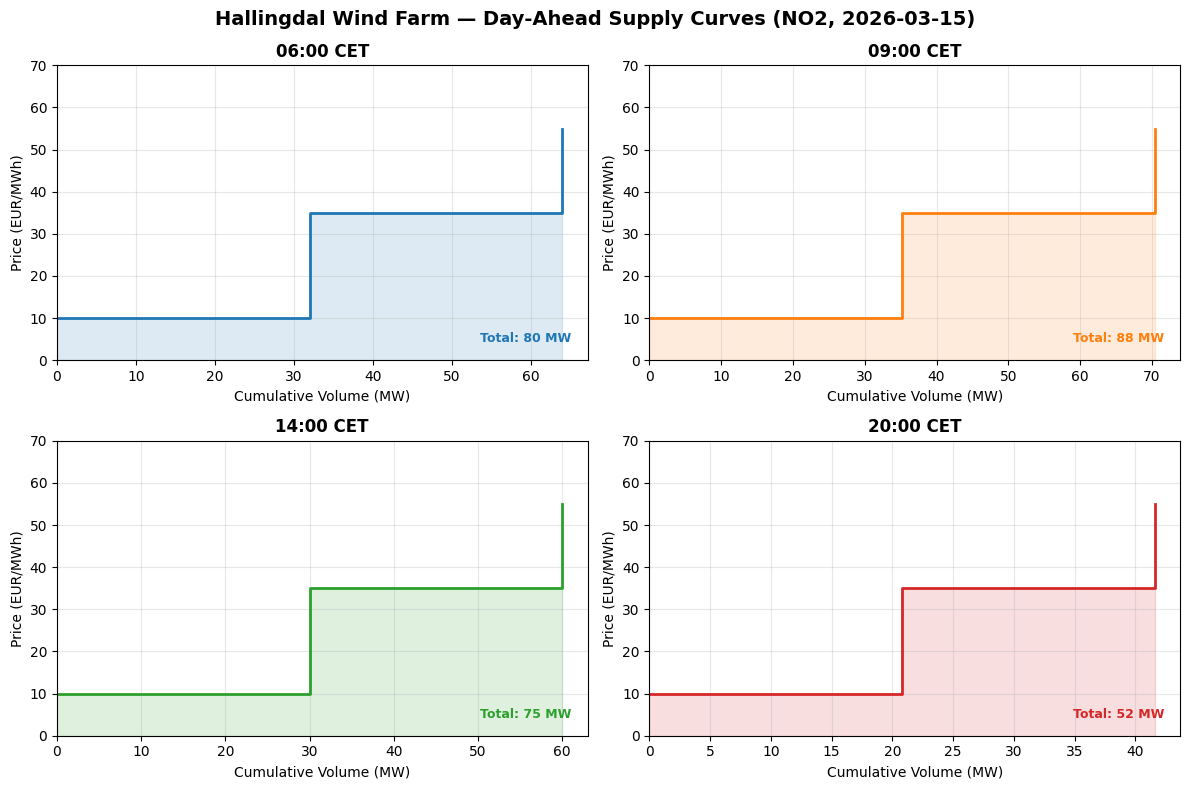

Figure saved: supply_curves.png


In [6]:
# Select representative MTUs: 06:00, 09:00, 14:00, 20:00 CET
plot_mtu_indices = [24, 36, 56, 80]  # 4 MTUs per hour × hours
plot_labels = ["06:00 CET", "09:00 CET", "14:00 CET", "20:00 CET"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False, sharey=False)
fig.suptitle(
    "Hallingdal Wind Farm — Day-Ahead Supply Curves (NO2, 2026-03-15)",
    fontsize=14, fontweight="bold"
)

for ax, idx, label, color in zip(axes.flat, plot_mtu_indices, plot_labels, colors):
    bid = bids[idx]
    steps = bid.curve.steps

    # Build step-function: cumulative volume on x-axis, price on y-axis
    cum_vol = [0.0]
    prices_stepped = []
    for step in steps:
        prices_stepped.append(float(step.price))
        prices_stepped.append(float(step.price))
        cum_vol.append(cum_vol[-1])
        cum_vol.append(cum_vol[-1] + float(step.volume))
    # Final horizontal segment
    x = cum_vol[:-1]
    y = prices_stepped

    ax.step(x, y, where="post", color=color, linewidth=2)
    ax.fill_between(x, y, alpha=0.15, color=color, step="post")
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Cumulative Volume (MW)")
    ax.set_ylabel("Price (EUR/MWh)")
    ax.set_ylim(0, 70)
    ax.set_xlim(0, None)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))
    ax.grid(True, alpha=0.3)

    # Annotate total volume
    total = float(bid.curve.total_volume)
    ax.text(0.97, 0.05, f"Total: {total:.0f} MW",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=9, color=color, fontweight="bold")

plt.tight_layout()
plt.savefig("supply_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved: supply_curves.png")

## 6. Visualisation — Volume Profile Over the Day

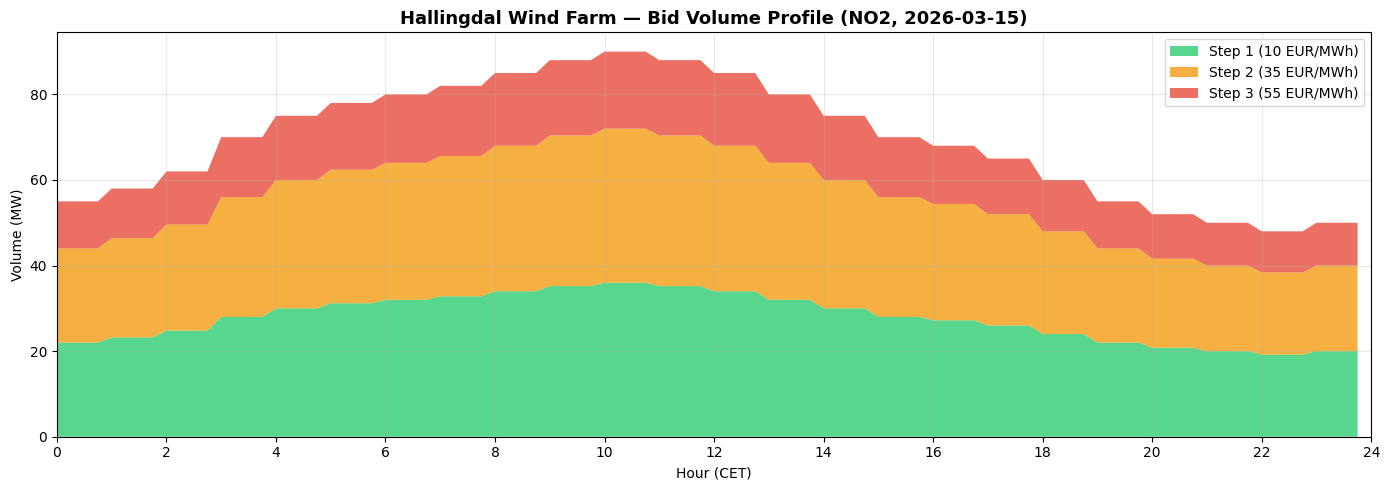

Figure saved: volume_profile.png


In [7]:
hours = [b.curve.mtu.start.astimezone(CET).hour + b.curve.mtu.start.astimezone(CET).minute / 60
         for b in bids]
volumes = [float(b.curve.total_volume) for b in bids]

# Volume by tier
vol_t1 = [float(b.curve.steps[0].volume) for b in bids]
vol_t2 = [float(b.curve.steps[1].volume) for b in bids]
vol_t3 = [float(b.curve.steps[2].volume) for b in bids]

fig, ax = plt.subplots(figsize=(14, 5))
ax.stackplot(
    hours, vol_t1, vol_t2, vol_t3,
    labels=[f"Step 1 ({float(PRICE_TIER_1):.0f} EUR/MWh)",
            f"Step 2 ({float(PRICE_TIER_2):.0f} EUR/MWh)",
            f"Step 3 ({float(PRICE_TIER_3):.0f} EUR/MWh)"],
    colors=["#2ecc71", "#f39c12", "#e74c3c"],
    alpha=0.8,
)
ax.set_title(
    "Hallingdal Wind Farm — Bid Volume Profile (NO2, 2026-03-15)",
    fontsize=13, fontweight="bold"
)
ax.set_xlabel("Hour (CET)")
ax.set_ylabel("Volume (MW)")
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 2))
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("volume_profile.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved: volume_profile.png")

## Summary

We've built **96 `SimpleBid` objects** covering a full 15-minute MTU day for Hallingdal Wind Farm:

- Each bid contains a **3-step supply curve** with volumes split 40/40/20% across price tiers
- The `PriceQuantityCurve` ensures steps are **sorted ascending** (EUPHEMIA supply convention)
- `simple_bid_from_curve` automatically assigns `direction=SELL` from the `SUPPLY` curve type
- All datetimes are **timezone-aware** (Europe/Oslo), rejecting naive datetimes at model creation
- Prices are **`Decimal`** throughout — no floating-point rounding errors

Next: see `02_block_bids.ipynb` for block and linked block bids with startup cost modelling.